In [16]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns 

In [17]:
df = pd.read_csv("Dataset/data.csv")

In [18]:
df.columns

Index(['id', 'event_type', 'latitude', 'longitude', 'endlatitude',
       'endlongitude', 'address', 'end_address', 'event_cause',
       'requires_road_closure', 'start_datetime', 'end_datetime', 'status',
       'authenticated', 'modified_datetime', 'map_file', 'direction',
       'description', 'veh_type', 'veh_no', 'corridor', 'priority',
       'cargo_material', 'reason_breakdown', 'age_of_truck', 'created_date',
       'route_path', 'client_id', 'created_by_id', 'last_modified_by_id',
       'assigned_to_police_id', 'citizen_accident_id', 'comment',
       'police_station', 'meta_data', 'kgid', 'resolved_at_address',
       'resolved_at_latitude', 'resolved_at_longitude', 'closed_by_id',
       'closed_datetime', 'resolved_by_id', 'resolved_datetime',
       'gba_identifier', 'zone', 'junction'],
      dtype='str')

In [19]:
print(df.shape)
print(df.dtypes)
print(df.head(10))
print(df.isnull().sum())
print(df.describe())

(8173, 46)
id                           str
event_type                   str
latitude                 float64
longitude                float64
endlatitude              float64
endlongitude             float64
address                      str
end_address                  str
event_cause                  str
requires_road_closure       bool
start_datetime               str
end_datetime                 str
status                       str
authenticated                str
modified_datetime            str
map_file                 float64
direction                    str
description                  str
veh_type                     str
veh_no                       str
corridor                     str
priority                     str
cargo_material               str
reason_breakdown             str
age_of_truck             float64
created_date                 str
route_path                   str
client_id                  int64
created_by_id                str
last_modified_by_id          str

In [20]:
print(df.dtypes)

id                           str
event_type                   str
latitude                 float64
longitude                float64
endlatitude              float64
endlongitude             float64
address                      str
end_address                  str
event_cause                  str
requires_road_closure       bool
start_datetime               str
end_datetime                 str
status                       str
authenticated                str
modified_datetime            str
map_file                 float64
direction                    str
description                  str
veh_type                     str
veh_no                       str
corridor                     str
priority                     str
cargo_material               str
reason_breakdown             str
age_of_truck             float64
created_date                 str
route_path                   str
client_id                  int64
created_by_id                str
last_modified_by_id          str
assigned_t

In [21]:
print(df.head(10))

           id event_type   latitude  longitude  endlatitude  endlongitude  \
0  FKID000000  unplanned  13.040004  77.518099     0.000000      0.000000   
1  FKID000001  unplanned  12.921876  77.645158     0.000000      0.000000   
2  FKID000002  unplanned  12.955622  77.585708     0.000000      0.000000   
3  FKID000003  unplanned  13.006147  77.579435    13.006239     77.579516   
4  FKID000004  unplanned  12.953980  77.585233     0.000000      0.000000   
5  FKID000005  unplanned  13.066485  77.599875          NaN           NaN   
6  FKID000006  unplanned  12.932870  77.487981     0.000000      0.000000   
7  FKID000007  unplanned  12.973175  77.600396     0.000000      0.000000   
8  FKID000008    planned  12.978836  77.599537          NaN           NaN   
9  FKID000009  unplanned  13.037354  77.654044     0.000000      0.000000   

                                             address  \
0  Mumbai Bengaluru Highway, Jalahalli Cross Junc...   
1  19th Main Road, Heavie Halcyon, Agara

In [22]:
print(df.isnull().sum())

id                          0
event_type                  0
latitude                    0
longitude                   0
endlatitude               169
endlongitude              169
address                     3
end_address              7486
event_cause                 0
requires_road_closure       0
start_datetime              0
end_datetime             7683
status                      0
authenticated               0
modified_datetime           0
map_file                 8173
direction                8130
description              1360
veh_type                 3286
veh_no                   3287
corridor                   20
priority                    2
cargo_material           7897
reason_breakdown         7897
age_of_truck             7897
created_date                0
route_path               8036
client_id                   0
created_by_id               2
last_modified_by_id         3
assigned_to_police_id    8045
citizen_accident_id      8045
comment                  8173
police_sta

In [23]:
print(df.describe())

          latitude    longitude  endlatitude  endlongitude  map_file  \
count  8173.000000  8173.000000  8004.000000   8004.000000       0.0   
mean     12.987076    77.596034     1.128050      6.678011       NaN   
std       0.060109     0.061193     3.736845     21.761316       NaN   
min      12.801041    77.308731     0.000000      0.000000       NaN   
25%      12.951635    77.556747     0.000000      0.000000       NaN   
50%      12.982847    77.589460     0.000000      0.000000       NaN   
75%      13.026867    77.625853     0.000000      0.000000       NaN   
max      13.267510    77.769403    59.860133     80.720691       NaN   

       age_of_truck    client_id  comment  meta_data  resolved_at_latitude  \
count    276.000000  8173.000000      0.0        0.0             74.000000   
mean     235.518116     1.009788      NaN        NaN             13.002599   
std      634.059816     0.098457      NaN        NaN              0.091377   
min        0.000000     1.000000      N

In [28]:
# Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(audit[audit.missing_count > 0].sort_values('missing_pct', ascending=False))

# Cardinality of key categoricals
for col in ['event_type', 'event_cause', 'zone', 'junction',
            'corridor', 'priority', 'status', 'direction', 'veh_type']:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().head(10))

# Inspect free-text / JSON columns
print(df['meta_data'].dropna().head(3))
print(df['description'].dropna().head(3))
print(df['route_path'].dropna().head(3))

                       missing_count  missing_pct
map_file                        8173       100.00
meta_data                       8173       100.00
comment                         8173       100.00
direction                       8130        99.47
resolved_at_longitude           8099        99.09
resolved_at_latitude            8099        99.09
resolved_at_address             8099        99.09
resolved_datetime               8099        99.09
resolved_by_id                  8099        99.09
citizen_accident_id             8045        98.43
assigned_to_police_id           8045        98.43
route_path                      8036        98.32
age_of_truck                    7897        96.62
cargo_material                  7897        96.62
reason_breakdown                7897        96.62
end_datetime                    7683        94.00
end_address                     7486        91.59
junction                        5663        69.29
closed_datetime                 5032        61.57


In [31]:
# Parse all datetime columns first
datetime_cols = ['start_datetime', 'end_datetime', 'resolved_datetime',
                 'closed_datetime', 'created_date', 'modified_datetime']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# TARGET 1: Resolution Duration (regression)
# How long from event start to resolution — primary target
df['resolution_duration_mins'] = (
    df['resolved_datetime'] - df['start_datetime']
).dt.total_seconds() / 60

# TARGET 2: Road Closure Required (binary classification)
# Will this event need a road closure?
df['road_closure_flag'] = df['requires_road_closure'].map(
    {'Yes': 1, 'No': 0, 'YES': 1, 'NO': 0,
     True: 1, False: 0, '1': 1, '0': 0}
).fillna(0).astype(int)

# TARGET 3: Priority Level (multiclass classification)
# What severity level should be assigned?
print(df['priority'].value_counts())
# Map based on what you see — example:
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['priority_encoded'] = df['priority'].map(priority_map)

# Quality filter for regression target
print("Negative durations:", (df['resolution_duration_mins'] < 0).sum())
print("Zero durations:", (df['resolution_duration_mins'] == 0).sum())
print("Very long (>24hr):", (df['resolution_duration_mins'] > 1440).sum())

# Keep only valid durations for regression modeling
df_regression = df[
    (df['resolution_duration_mins'] > 0) &
    (df['resolution_duration_mins'] < 1440)  # cap at 24 hours
].copy()

print(f"\nRegression dataset size: {df_regression.shape[0]} rows")
print(df_regression['resolution_duration_mins'].describe())

priority
High    5030
Low     3141
Name: count, dtype: int64
Negative durations: 0
Zero durations: 0
Very long (>24hr): 3

Regression dataset size: 69 rows
count     69.000000
mean      77.107340
std      121.357682
min        3.311959
25%       34.199984
50%       57.640570
75%       83.154634
max      980.117226
Name: resolution_duration_mins, dtype: float64


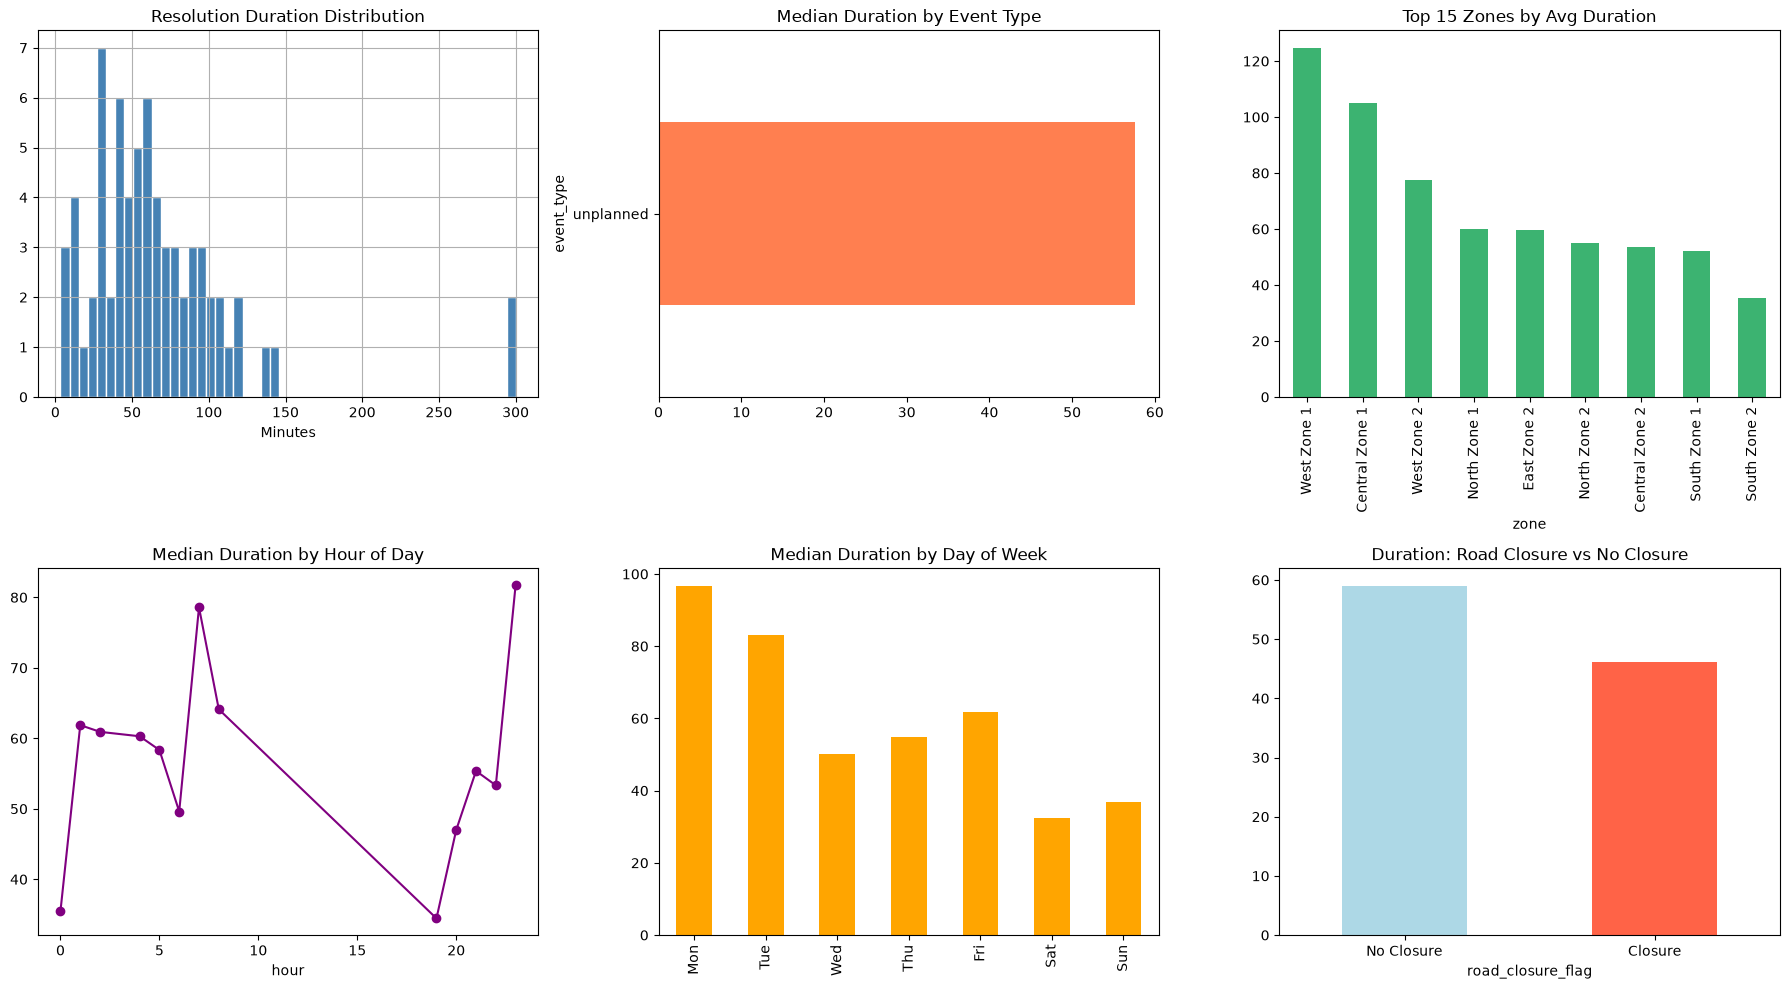

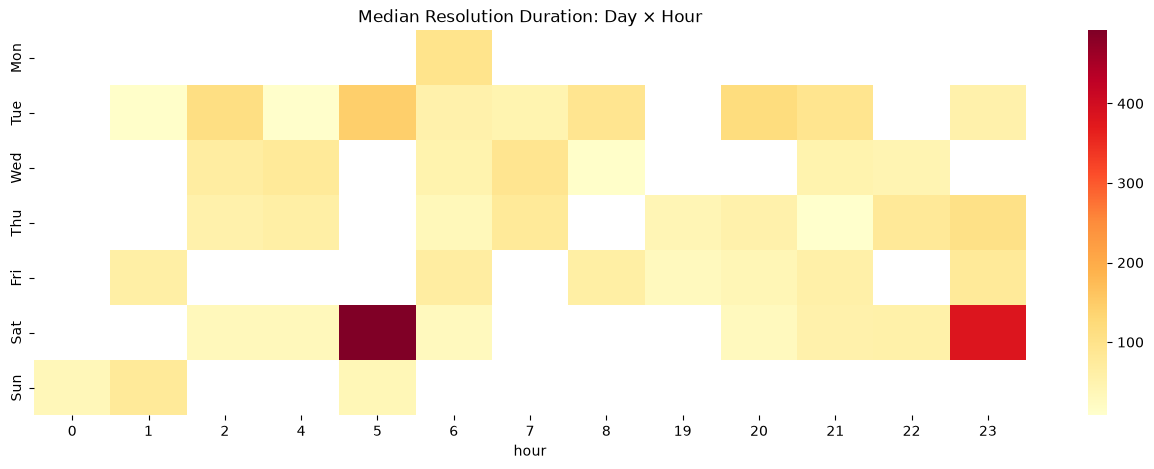

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target distribution
df_regression['resolution_duration_mins'].clip(0, 300).hist(
    bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Resolution Duration Distribution')
axes[0,0].set_xlabel('Minutes')

# 2. Event type vs duration
event_dur = df_regression.groupby('event_type')['resolution_duration_mins'].median().sort_values()
event_dur.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Median Duration by Event Type')

# 3. Zone hotspots
zone_dur = df_regression.groupby('zone')['resolution_duration_mins'].mean().sort_values(ascending=False).head(15)
zone_dur.plot(kind='bar', ax=axes[0,2], color='mediumseagreen')
axes[0,2].set_title('Top 15 Zones by Avg Duration')

# 4. Hourly pattern
df_regression['hour'] = df_regression['start_datetime'].dt.hour
hourly = df_regression.groupby('hour')['resolution_duration_mins'].median()
hourly.plot(kind='line', marker='o', ax=axes[1,0], color='purple')
axes[1,0].set_title('Median Duration by Hour of Day')

# 5. Day of week pattern
df_regression['day_of_week'] = df_regression['start_datetime'].dt.dayofweek
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_dur = df_regression.groupby('day_of_week')['resolution_duration_mins'].median()
dow_dur.index = dow_labels
dow_dur.plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Median Duration by Day of Week')

# 6. Road closure vs duration
df_regression.groupby('road_closure_flag')['resolution_duration_mins'].median().plot(
    kind='bar', ax=axes[1,2], color=['lightblue', 'tomato'])
axes[1,2].set_title('Duration: Road Closure vs No Closure')
axes[1,2].set_xticklabels(['No Closure', 'Closure'], rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# Heatmap: hour × day_of_week
pivot = df_regression.pivot_table(
    values='resolution_duration_mins',
    index='day_of_week',
    columns='hour',
    aggfunc='median'
)
pivot.index = dow_labels
plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', fmt='.0f', annot=False)
plt.title('Median Resolution Duration: Day × Hour')
plt.savefig('heatmap_day_hour.png', dpi=150)
plt.show()